## 📦 Import Libraries
Import core libraries for single-cell RNA-seq analysis:
- **scanpy** — main toolkit for single-cell analysis (Python equivalent of Seurat)
- **anndata** — data structure for storing single-cell data (cells × genes matrix)
- **pandas** — metadata handling and tabular data manipulation
- **numpy** — numerical operations on arrays
- **matplotlib** — base plotting library for figure generation
- **os** — file path and directory management

Settings:
- `verbosity = 3` — print detailed progress messages during analysis
- `figdir` — save all figures automatically to the figures folder
- `set_figure_params` — standardize figure resolution and background color

In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

sc.settings.verbosity = 3
sc.settings.figdir = "../figures/"
sc.settings.set_figure_params(dpi=100, facecolor="white")

## 📂 Load Sample Manifest
Load the sample manifest generated in Script 01.
This table maps each sample title to its disease condition
(Type 1 Diabetes vs Lean Control) and will be used to assign
metadata to each AnnData object during loading.

In [ ]:
manifest = pd.read_csv("../output/sample_manifest.csv", index_col=0)
print(f"Total samples: {len(manifest)}")
print(f"\nDisease distribution:")
print(manifest['disease'].value_counts())
manifest.head()

## 3️⃣ Load Raw 10X Data for Each Sample
Load the raw 10X Genomics count matrices for all 40 samples using
scanpy's `read_10x_mtx()` function. Each sample is loaded individually
into its own AnnData object, and key metadata (sample title, disease
condition, GSM accession ID) is attached to each cell.

Each AnnData object at this stage represents:
- **Rows** — individual cells (barcodes)
- **Columns** — genes (features)
- **Values** — raw UMI counts (unprocessed)

In [ ]:
RAW_DIR = "../data/raw"
adatas = {}

for idx, row in manifest.iterrows():
    sample = row['Title']
    sample_dir = os.path.join(RAW_DIR, sample)
    
    # Load 10X matrix
    adata = sc.read_10x_mtx(
        sample_dir,
        var_names='gene_symbols',
        cache=True
    )
    
    # Attach metadata to every cell
    adata.obs['sample']   = sample
    adata.obs['disease']  = row['disease']
    adata.obs['GSM']      = row['GSM']
    adata.obs['tissue']   = row['tissue']
    
    adatas[sample] = adata
    print(f"✅ Loaded {sample}: {adata.shape[0]} cells × {adata.shape[1]} genes")

print(f"\n🎉 All {len(adatas)} samples loaded!")

## 4️⃣ Pre-QC Summary
Summarize the total number of cells and genes across all 40 samples
before any quality control filtering. This gives us a baseline to
compare against after QC, showing how many cells were removed.

In [ ]:
total_cells = sum([adata.shape[0] for adata in adatas.values()])
total_genes = list(adatas.values())[0].shape[1]

print(f"Total cells before QC : {total_cells:,}")
print(f"Total genes per sample: {total_genes:,}")
print(f"Total samples         : {len(adatas)}")

cell_counts = pd.DataFrame({
    'Sample'  : list(adatas.keys()),
    'Disease' : [adata.obs['disease'].iloc[0] for adata in adatas.values()],
    'Cells'   : [adata.shape[0] for adata in adatas.values()]
})
cell_counts.index = range(1, len(cell_counts) + 1)
cell_counts.index.name = "No."
cell_counts

## 5️⃣ Calculate QC Metrics Per Sample
For each sample individually, calculate key quality control metrics:
- **n_genes_by_counts** — number of genes detected per cell
- **total_counts** — total UMI counts per cell (sequencing depth)
- **pct_counts_mt** — percentage of counts from mitochondrial genes (marker of dying/stressed cells)
- **pct_counts_ribo** — percentage of counts from ribosomal genes (marker of low-information cells)

Mitochondrial genes are identified by the **MT-** prefix.
Ribosomal genes are identified by **RPS** and **RPL** prefixes.
QC metrics are calculated per sample before merging to allow
sample-specific inspection and filtering.

In [ ]:
for sample, adata in adatas.items():
    # Flag mitochondrial and ribosomal genes
    adata.var['mt']   = adata.var_names.str.startswith('MT-')
    adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))

    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=['mt', 'ribo'],
        percent_top=None,
        log1p=False,
        inplace=True
    )

print("✅ QC metrics calculated for all samples")

# Preview metrics for first sample
first = list(adatas.values())[0]
print(f"\nQC columns added to obs:")
print([col for col in first.obs.columns if any(
    x in col for x in ['counts', 'genes', 'pct']
)])

## 6️⃣ Visualize QC Metrics Per Sample (Pre-Filtering)
Generate violin plots of the four key QC metrics across all 40 samples
to visually inspect cell quality distributions before any filtering.
Each metric is plotted separately for clarity and saved to the figures folder.

### Metrics Visualized:
- **Genes per Cell** (`n_genes_by_counts`) — cell complexity; too low = empty droplet, too high = doublet
- **Total UMI Counts** (`total_counts`) — sequencing depth; too low = poor capture, too high = doublet
- **Mitochondrial %** (`pct_counts_mt`) — cell stress/death; high % indicates dying cells
- **Ribosomal %** (`pct_counts_ribo`) — low information cells; very high % adds noise

### Key Observations (Pre-Filtering):
- Many cells show **MT% approaching 100%** → aggressive mitochondrial filtering is required
- Some cells show **>8,000 genes** and **>100,000 UMIs** → likely doublets
- Some cells show **near-zero counts** → empty droplets
- These low-quality cells will be removed in the next step

In [ ]:
metrics = [
    ('n_genes_by_counts', 'Genes per Cell',    '#4C72B0'),
    ('total_counts',      'Total UMI Counts',  '#DD8452'),
    ('pct_counts_mt',     'Mitochondrial %',   '#C44E52'),
    ('pct_counts_ribo',   'Ribosomal %',       '#55A868')
]

for metric, label, color in metrics:
    fig, ax = plt.subplots(figsize=(24, 6))

    sc.pl.violin(
        adata_all,
        keys=metric,
        groupby='sample',
        rotation=90,
        ax=ax,
        show=False,
        color=color,
        stripplot=False
    )

    ax.set_title(f"Pre-Filtering: {label}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    fname = f"../figures/preqc_{metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {fname}")

## 7️⃣ QC Filtering
Remove low-quality cells from each sample based on the four QC metrics
inspected in the previous step. Filtering is applied per sample using
fixed thresholds consistent with the R/Seurat pipeline, allowing direct
comparison between both workflows.

### Filtering Thresholds:
| Metric | Threshold | Removes |
|---|---|---|
| `n_genes_by_counts` | 200 – 7,000 | Empty droplets & doublets |
| `total_counts` | 500 – 50,000 | Poor capture & doublets |
| `pct_counts_mt` | < 20% | Dying/stressed cells |
| `pct_counts_ribo` | < 50% | Low information cells |

In [ ]:
cells_before = adata_all.shape[0]

# Apply QC filters
adata_all = adata_all[
    (adata_all.obs['n_genes_by_counts'] >= 200) &
    (adata_all.obs['n_genes_by_counts'] <= 7000) &
    (adata_all.obs['total_counts'] >= 500) &
    (adata_all.obs['total_counts'] <= 50000) &
    (adata_all.obs['pct_counts_mt'] < 20) &
    (adata_all.obs['pct_counts_ribo'] < 50)
].copy()

cells_after  = adata_all.shape[0]
cells_removed = cells_before - cells_after

print(f"Cells before filtering : {cells_before:,}")
print(f"Cells after filtering  : {cells_after:,}")
print(f"Cells removed          : {cells_removed:,} ({100*cells_removed/cells_before:.1f}%)")

## 8️⃣ Visualize QC Metrics Per Sample (Post-Filtering)
Generate violin plots of the four QC metrics after filtering to confirm
that low-quality cells have been successfully removed. Comparing these
plots with the pre-filtering plots demonstrates the effectiveness of
our QC strategy.

### Expected After Filtering:
- **Genes per Cell** — distribution centered between 200–7,000
- **Total UMI Counts** — distribution centered between 500–50,000
- **Mitochondrial %** — all cells below 20% threshold
- **Ribosomal %** — all cells below 50% threshold

In [ ]:
metrics = [
    ('n_genes_by_counts', 'Genes per Cell',    '#4C72B0'),
    ('total_counts',      'Total UMI Counts',  '#DD8452'),
    ('pct_counts_mt',     'Mitochondrial %',   '#C44E52'),
    ('pct_counts_ribo',   'Ribosomal %',       '#55A868')
]

for metric, label, color in metrics:
    fig, ax = plt.subplots(figsize=(24, 6))

    sc.pl.violin(
        adata_all,
        keys=metric,
        groupby='sample',
        rotation=90,
        ax=ax,
        show=False,
        color=color,
        stripplot=False
    )

    ax.set_title(f"Post-Filtering: {label}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.tick_params(axis='x', labelsize=8)

    plt.tight_layout()
    fname = f"../figures/postqc_{metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {fname}")

## 9️⃣ Save Filtered AnnData Object
Save the quality-controlled merged AnnData object to disk as an `.h5ad` file.
This is the standard file format for single-cell data in Python, equivalent
to the `.rds` format used in R/Seurat.

Saving at this stage ensures:
- QC filtering results are preserved
- Downstream scripts can load directly without repeating QC
- The object can be shared and reproduced independently

In [ ]:
# Save filtered object
out_path = "../data/processed/GSE279086_qc_filtered.h5ad"
adata_all.write_h5ad(out_path)
print(f"✅ Saved: {out_path}")
print(f"   Cells : {adata_all.shape[0]:,}")
print(f"   Genes : {adata_all.shape[1]:,}")

# Check file size
import os
size_mb = os.path.getsize(out_path) / (1024 * 1024)
print(f"   Size  : {size_mb:.1f} MB")

## 🔟 Export Pre and Post QC Plots as a Single PDF
Combine all 8 QC violin plots (4 pre-filtering and 4 post-filtering)
into a single PDF file for easy sharing and portfolio presentation.

NameError: name 'adata_before' is not defined

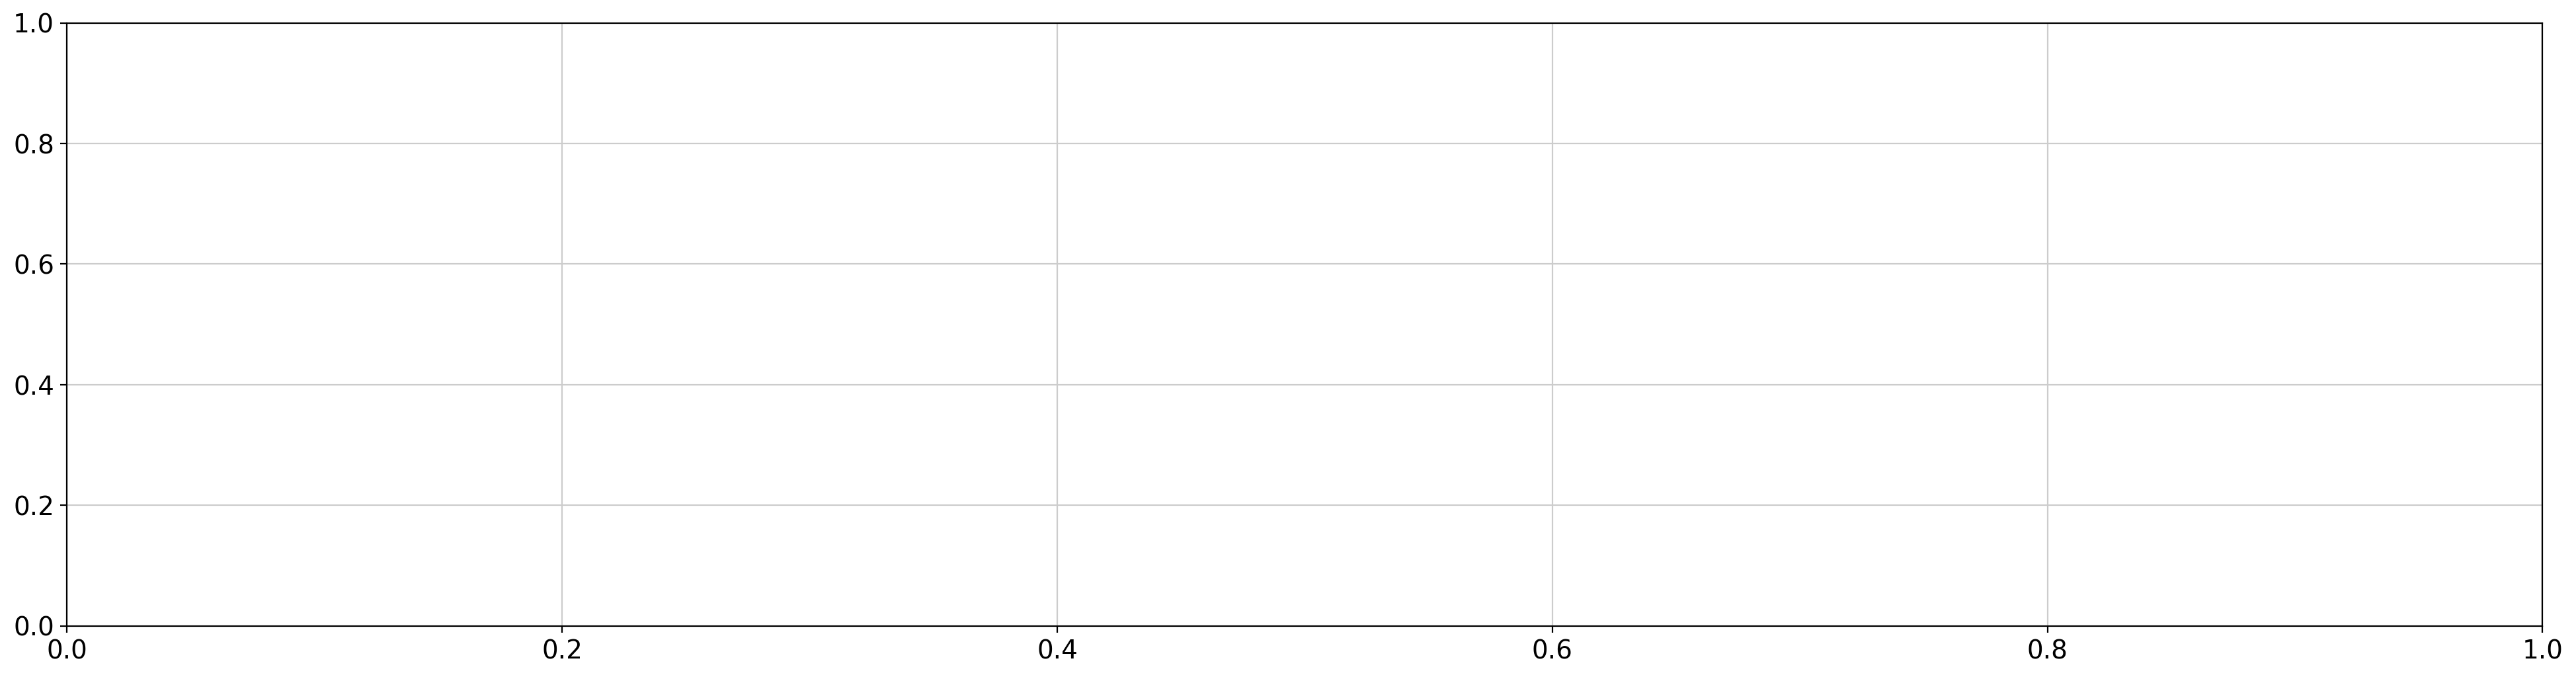

In [33]:
from matplotlib.backends.backend_pdf import PdfPages

metrics = [
    ('n_genes_by_counts', 'Genes per Cell',   '#4C72B0'),
    ('total_counts',      'Total UMI Counts', '#DD8452'),
    ('pct_counts_mt',     'Mitochondrial %',  '#C44E52'),
    ('pct_counts_ribo',   'Ribosomal %',      '#55A868')
]

pdf_path = "../figures/QC_Pre_Post_Filtering.pdf"

with PdfPages(pdf_path) as pdf:

    # ── Pre-filtering plots ───────────────────────────────────
    for metric, label, color in metrics:
        fig, ax = plt.subplots(figsize=(24, 6))
        sc.pl.violin(
            adata_before,
            keys=metric,
            groupby='sample',
            rotation=90,
            ax=ax,
            show=False,
            color=color,
            stripplot=False
        )
        ax.set_title(f"Pre-Filtering: {label}", fontsize=16, fontweight='bold')
        ax.set_xlabel("Sample", fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.tick_params(axis='x', labelsize=8)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()
        print(f"✅ Added Pre-Filtering: {label}")

    # ── Post-filtering plots ──────────────────────────────────
    for metric, label, color in metrics:
        fig, ax = plt.subplots(figsize=(24, 6))
        sc.pl.violin(
            adata_all,
            keys=metric,
            groupby='sample',
            rotation=90,
            ax=ax,
            show=False,
            color=color,
            stripplot=False
        )
        ax.set_title(f"Post-Filtering: {label}", fontsize=16, fontweight='bold')
        ax.set_xlabel("Sample", fontsize=12)
        ax.set_ylabel(label, fontsize=12)
        ax.tick_params(axis='x', labelsize=8)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close()
        print(f"✅ Added Post-Filtering: {label}")

print(f"\n🎉 Saved: {pdf_path}")